<a href="https://colab.research.google.com/github/Lilli-Ai/langgraph-tour-price-agent/blob/main/tour_price_agent_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tour Price in AMD Agent (LangGraph)

In [2]:
!pip install -q -U langgraph langchain-google-genai

In [3]:
from google.colab import userdata
import os

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

print("GOOGLE_API_KEY loaded:", bool(os.environ["GOOGLE_API_KEY"]))

GOOGLE_API_KEY loaded: True


In [4]:
import requests

URL = "https://www.aeb.am/en/"
headers = {"User-Agent": "Mozilla/5.0"}   # представляемся браузером

response = requests.get(URL, headers=headers, timeout=20)
print("Status:", response.status_code)
print("Page size:", len(response.text), "characters")

html = response.text
pos = html.find("USD")                    # где в HTML впервые встречается "USD"
print("First 'USD' at position:", pos)
print(html[pos - 300 : pos + 700])        # кусок HTML вокруг него

Status: 200
Page size: 355073 characters
First 'USD' at position: 174389
                                <div class="slide-ratio-container">
                                    <div class="slide-content">
                                        <div class="slide-title lead fw-medium mb-3">
                                            Armeconombank to Place New Tranche of USD-Denominated Bonds
                                        </div>
                                        <div class="slide-desc mb-3">
                                            
                                        </div>
                                        <div class="slide-date">
                                            22.09.2026
                                        </div>
                                    </div>
                                </div>
                            </a>
                                                    <!-- Main Slider Items -->
                            <a href

In [5]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

# элементы, весь текст которых — ровно "USD"
usd_tags = soup.find_all(string=lambda s: s and s.strip() == "USD")
print("Found:", len(usd_tags))

# для каждого печатаем "строку таблицы" вокруг него (родитель родителя)
for i, tag in enumerate(usd_tags):
    row = tag.parent.parent
    print(f"\n===== {i} =====")
    print(row.prettify()[:1500])

Found: 5

===== 0 =====
<div aria-label="Radio button group" class="btn-group radio" role="group">
 <input autocomplete="off" checked="" class="btn-check d-none currency-option-range" data-dedline="#rangeDay" data-max="100000000" data-maxpercent="100" data-min="100000" data-minpercent="1" data-percent="#rangePercent" data-step="50000" data-target="#loan-amount" data-unit="AMD" id="currency-option-amd" name="options" type="radio"/>
 <label class="btn" for="currency-option-amd">
  AMD
 </label>
 <input autocomplete="off" class="btn-check d-none currency-option-range" data-dedline="#rangeDay" data-max="100000" data-maxpercent="100000" data-min="200" data-minpercent="10" data-percent="#rangePercent" data-step="100" data-target="#loan-amount" data-unit="USD" id="currency-option-usd" name="options" step="100" type="radio"/>
 <label class="btn" for="currency-option-usd">
  USD
 </label>
 <input autocomplete="off" class="btn-check d-none currency-option-range" data-dedline="#rangeDay" data-max

In [6]:
label = soup.find("span", class_="__currency-lbl-usd")

# поднимаемся на 1, 2, 3 уровня вверх и смотрим, где появятся цифры
node = label
for level in range(1, 4):
    node = node.parent
    print(f"\n===== level {level}: <{node.name}> class={node.get('class')} =====")
    print(node.get_text(" | ", strip=True)[:300])


===== level 1: <div> class=None =====
USD

===== level 2: <td> class=None =====
USD

===== level 3: <tr> class=None =====
USD | 360 | 364.5 | 362.82


In [7]:
def get_aeb_rate(currency: str = "USD") -> dict:
    """
    Get today's exchange rates of Armeconombank (AEB) for a currency against AMD.

    Args:
        currency: Currency code, e.g. "USD", "EUR", "RUB".

    Returns:
        A dict with buy rate, sell rate and Central Bank rate in AMD.
    """
    try:
        response = requests.get(URL, headers=headers, timeout=20)
        soup = BeautifulSoup(response.text, "html.parser")

        label = soup.find("span", class_=f"__currency-lbl-{currency.lower()}")
        if label is None:
            return {"error": f"Currency {currency} not found on AEB website"}

        row = label.find_parent("tr")                     # строка таблицы
        cells = [td.get_text(strip=True) for td in row.find_all("td")]
        # cells = ["USD", "360", "364.5", "362.82"]

        def to_number(text):
            return float(text) if text not in ("", "-") else None

        return {
            "currency": currency.upper(),
            "buy": to_number(cells[1]),
            "sell": to_number(cells[2]),
            "central_bank": to_number(cells[3]),
            "source": "Armeconombank (aeb.am)",
        }

    except Exception as e:
        return {"error": f"Could not get rates: {e}"}


# проверка без агента
print(get_aeb_rate("USD"))
print(get_aeb_rate("EUR"))
print(get_aeb_rate("XYZ"))

{'currency': 'USD', 'buy': 360.0, 'sell': 364.5, 'central_bank': 362.82, 'source': 'Armeconombank (aeb.am)'}
{'currency': 'EUR', 'buy': 404.0, 'sell': 415.0, 'central_bank': 409.7, 'source': 'Armeconombank (aeb.am)'}
{'error': 'Currency XYZ not found on AEB website'}


In [8]:
def quote_price(price: float, sell_rate: float, markup: float = 2) -> dict:
    """
    Calculate the tour package price in AMD using the tour operator's bank rule:
    price in AMD = price in foreign currency × (bank sell rate + markup).

    Args:
        price: Package price in foreign currency (e.g. 1350 for 1350 USD).
        sell_rate: The bank's sell rate for that currency in AMD.
        markup: AMD added to the sell rate. Default 2.

    Returns:
        A dict with the applied rate and the total price in AMD.
    """
    applied_rate = sell_rate + markup
    total_amd = round(price * applied_rate)

    return {
        "price": price,
        "sell_rate": sell_rate,
        "markup": markup,
        "applied_rate": applied_rate,
        "total_amd": total_amd,
    }


# проверка без агента
print(quote_price(1350, 364.5))

{'price': 1350, 'sell_rate': 364.5, 'markup': 2, 'applied_rate': 366.5, 'total_amd': 494775}


In [9]:
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 1. модель (та же, что в двух прошлых агентах)
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

# 2. tools агента и привязка к модели
tools = [get_aeb_rate, quote_price]
llm_with_tools = llm.bind_tools(tools)

# 3. State — здесь только сообщения, картинки нет
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("Tools:", [t.__name__ for t in tools])

Tools: ['get_aeb_rate', 'quote_price']


In [10]:
from langchain_core.messages import SystemMessage

def assistant(state: AgentState):
    sys_msg = SystemMessage(content="""
You are a pricing assistant for a travel agency in Armenia.
Tour operators give package prices in foreign currency (USD, EUR, ...).
The agency must quote the price to the tourist in AMD using this rule of the partner bank (Armeconombank):
price in AMD = package price × (AEB sell rate + 2 AMD).

Rules:
- Always get today's rate with the get_aeb_rate tool. Never use a rate from memory.
- Always calculate with the quote_price tool. Never calculate in your head.
- If the currency is not found or the rate is missing, say so clearly and do not guess.
- If the price or currency is not clear from the message, ask the user.
- Answer shortly: package price, AEB sell rate, applied rate (+2), and the final price in AMD.
""")

    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

print("assistant node ready")

assistant node ready


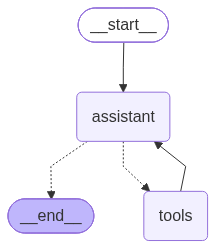

In [11]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

builder = StateGraph(AgentState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [12]:
from langchain_core.messages import HumanMessage

question = "The tour operator sent a package to Dubai for 1350 USD. How much should we quote the tourist in AMD?"

result = react_graph.invoke({"messages": [HumanMessage(content=question)]})

for m in result["messages"]:
    m.pretty_print()

print("\n===== FINAL ANSWER =====")
print(result["messages"][-1].text)

================================ Human Message =================================

The tour operator sent a package to Dubai for 1350 USD. How much should we quote the tourist in AMD?
================================== Ai Message ==================================

[]
Tool Calls:
  get_aeb_rate (call_140113)
 Call ID: call_140113
  Args:
    currency: USD
================================= Tool Message =================================
Name: get_aeb_rate

{"currency": "USD", "buy": 360.0, "sell": 364.5, "central_bank": 362.82, "source": "Armeconombank (aeb.am)"}
================================== Ai Message ==================================

[]
Tool Calls:
  quote_price (call_85530)
 Call ID: call_85530
  Args:
    price: 1350
    sell_rate: 364.5
    markup: 2
================================= Tool Message =================================
Name: quote_price

{"price": 1350.0, "sell_rate": 364.5, "markup": 2.0, "applied_rate": 366.5, "total_amd": 494775}
================================

In [13]:
tests = [
    "Package to Paris costs 980 EUR. Price in AMD?",       # другая валюта
    "How much is 1350 in drams?",                          # валюта не указана
]

for q in tests:
    result = react_graph.invoke({"messages": [HumanMessage(content=q)]})
    tools_used = [tc["name"] for m in result["messages"] for tc in getattr(m, "tool_calls", [])]
    print("Q:", q)
    print("Tools used:", tools_used)
    print("A:", result["messages"][-1].text)
    print("-" * 60)

Q: Package to Paris costs 980 EUR. Price in AMD?
Tools used: ['get_aeb_rate', 'quote_price']
A: - Package price: 980 EUR
- AEB EUR sell rate: 415 AMD
- Applied rate (+2 AMD): 417 AMD
- Final price in AMD: 408,660 AMD
------------------------------------------------------------
Q: How much is 1350 in drams?
Tools used: ['get_aeb_rate', 'quote_price']
A: - Package price: 1350 USD
- AEB sell rate: 364.50 AMD
- Applied rate (sell + 2): 366.50 AMD
- Final price in AMD: 494,775 AMD
------------------------------------------------------------


In [15]:
def assistant(state: AgentState):
    sys_msg = SystemMessage(content="""
You are a pricing assistant for a travel agency in Armenia.
Tour operators give package prices in foreign currency (USD, EUR, ...).
The agency must quote the price to the tourist in AMD using this rule of the partner bank (Armeconombank):
price in AMD = package price × (AEB sell rate + 2 AMD).

STEP 0 - CHECK THE INPUT FIRST:
- The user's message must contain BOTH a price AND a currency (for example "1350 USD" or "980 EUR").
- Never assume a currency. "Dollars" or "$" means USD, "euro" or "€" means EUR. A number alone has NO currency.
- If the currency or the price is missing, do NOT call any tool. Ask the user which currency the package price is in.

Rules:
- Always get today's rate with the get_aeb_rate tool. Never use a rate from memory.
- Always calculate with the quote_price tool. Never calculate in your head.
- If the currency is not found or the rate is missing, say so clearly and do not guess.
- Answer shortly: package price, AEB sell rate, applied rate (+2), and the final price in AMD.
""")

    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}


# граф нужно собрать заново: старый граф "запомнил" старую функцию assistant
builder = StateGraph(AgentState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

print("assistant v2 + graph rebuilt")

assistant v2 + graph rebuilt


### Evaluation after prompt fix

In [16]:
tests = [
    "Package to Paris costs 980 EUR. Price in AMD?",       # другая валюта
    "How much is 1350 in drams?",                          # валюта не указана
]

for q in tests:
    result = react_graph.invoke({"messages": [HumanMessage(content=q)]})
    tools_used = [tc["name"] for m in result["messages"] for tc in getattr(m, "tool_calls", [])]
    print("Q:", q)
    print("Tools used:", tools_used)
    print("A:", result["messages"][-1].text)
    print("-" * 60)

Q: Package to Paris costs 980 EUR. Price in AMD?
Tools used: ['get_aeb_rate', 'quote_price']
A: - Package price: 980 EUR
- AEB sell rate: 415 AMD
- Applied rate (+2 AMD): 417 AMD
- Final price in AMD: 408,660 AMD
------------------------------------------------------------
Q: How much is 1350 in drams?
Tools used: []
A: The user's message contains a price (1350) but no currency. 

Which currency is the package price in (e.g., USD, EUR, RUB)?
------------------------------------------------------------
